In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('heart_disease_uci.csv')

In [7]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
df = df.drop(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], axis=1)

In [9]:
df.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [10]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [11]:
missing_values = df.isnull().sum()
print(missing_values)

id           0
age          0
trestbps    59
chol        30
thalch      55
oldpeak     62
num          0
dtype: int64


In [12]:
df.shape

(920, 7)

In [13]:
df_cleaned = df.dropna()

In [15]:
df_cleaned.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [17]:
df_cleaned.shape

(827, 7)

In [18]:
import seaborn as sns

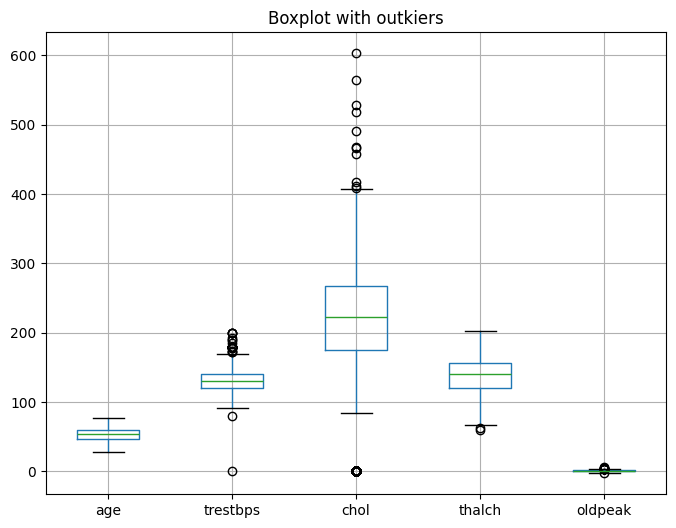

In [19]:
plt.figure(figsize=(8,6))
df.boxplot(column=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'])
plt.title('Boxplot with outkiers')
plt.show()

In [38]:
def remove_outliers(df, columns=None):
    clean_df = df.copy()
    
    for col in columns: 
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]
        
        return clean_df

In [40]:
columns = [ 'trestbps', 'chol', 'thalch', 'oldpeak']

df_cleaned = remove_outliers(df_cleaned, columns)

In [41]:
df_cleaned.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [42]:
df_cleaned.shape

(800, 7)

In [43]:
df_cleaned.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,429.79625,53.057500,130.708750,201.186250,137.960000,0.872750,0.961250
std,257.33297,9.415014,16.187077,109.259375,25.754077,1.088802,1.115259
min,1.00000,28.000000,92.000000,0.000000,60.000000,-2.600000,0.000000
25%,207.75000,46.000000,120.000000,178.750000,120.000000,0.000000,0.000000
50%,425.50000,54.000000,130.000000,224.000000,140.000000,0.500000,1.000000
75%,643.25000,60.000000,140.000000,267.000000,158.000000,1.500000,2.000000
max,920.00000,77.000000,170.000000,603.000000,202.000000,6.200000,4.000000
